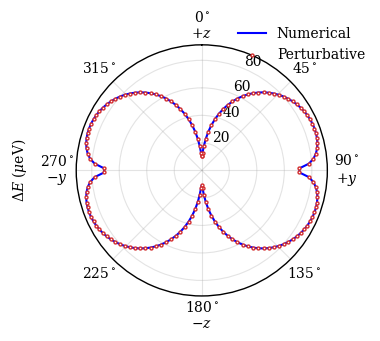

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np


# ==============================================================
#                         INPUT FILE
# ==============================================================

N = 70
L = 300
E = 7.0
kx = 0.001

data_file = f"E_rotation_N{N}_L{L}_E{E:.2f}Vum_kx{kx}.dat"



# ==============================================================
#                      PLOT APPEARANCE
# ==============================================================

plt.rcParams.update({
    "figure.figsize": [4.5, 4],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8
})


def prepare_polar_axis(ax):
    """Use the same angular convention as the electric-field rotation."""

    # theta = 0: E || +z; theta = 90 degrees: E || +y
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    ax.set_xticks(np.deg2rad([0, 45, 90, 135, 180, 225, 270, 315]))
    ax.set_xticklabels(
        [
            r"$0^\circ$" + "\n" + r"$+z$",
            r"$45^\circ$",
            r"$90^\circ$" + "\n" + r"$+y$",
            r"$135^\circ$",
            r"$180^\circ$" + "\n" + r"$-z$",
            r"$225^\circ$",
            r"$270^\circ$" + "\n" + r"$-y$",
            r"$315^\circ$",
        ]
    )

    ax.grid(alpha=0.35)
    ax.spines["polar"].set_linewidth(1.0)
    ax.set_rlabel_position(22.5)


# ==============================================================
#                         LOAD DATA
#
# 0: theta_deg
# 1: Ey_V_per_um
# 2: Ez_V_per_um
# 3: GS1_meV
# 4: GS2_meV
# 5: numerical_gap_microeV
# 6: alpha_eV_A
# 7: perturbative_gap_k1_microeV
# ==============================================================

data = np.loadtxt(data_file, comments="#")

if data.ndim != 2 or data.shape[1] < 8:
    raise ValueError(
        f"Expected at least 8 columns in {data_file}, "
        f"but found shape {data.shape}."
    )

theta = np.deg2rad(data[:, 0])
numerical_splitting = data[:, 5]
perturbative_splitting = data[:, 7]

# 1 eV Angstrom = 100 meV nm
alpha_meV_nm = 100.0 * data[:, 6]


# ==============================================================
#           FIGURE 1: NUMERICAL AND PERTURBATIVE SPLITTING
# ==============================================================

fig1, ax1 = plt.subplots(
    figsize=(4, 4),
    subplot_kw={"projection": "polar"},
)

prepare_polar_axis(ax1)

# Numerical result: solid line
ax1.plot(
    theta,
    numerical_splitting,
    color="blue",
    linestyle="-",
    linewidth=1.5,
    label="Numerical",
    zorder=3,
)

# Perturbative result: open-circle scatter points
ax1.scatter(
    theta,
    perturbative_splitting,
    color="#D32F2F",
    label="Perturbative",
    marker="o",
    s=4.5,
    facecolors="white",
    edgecolors="#D32F2F",
    linewidths=1.0,
    zorder=4,
)

ax1.set_ylabel(
    r"$\Delta E~(\mu\mathrm{eV})$",
    labelpad=34,
)
ax1.legend(
    loc="upper right",
    bbox_to_anchor=(1.20, 1.12),
    frameon=False,
)

fig1.tight_layout()
fig1.savefig(
    f"polar_splitting_numerical_perturbative_N{N}_L{L}_E{E:.2f}Vum_kx{kx}.png",
    dpi=400,
    bbox_inches="tight",
)


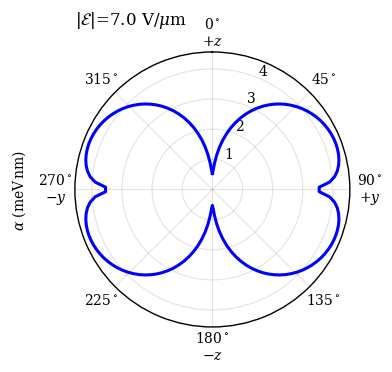

In [2]:


# ==============================================================
#                  FIGURE 2: RASHBA COEFFICIENT
# ==============================================================

fig2, ax2 = plt.subplots(
    figsize=(4, 4),
    subplot_kw={"projection": "polar"},
)

prepare_polar_axis(ax2)

ax2.plot(
    theta,
    alpha_meV_nm,
    color="blue",
    linewidth=2.2,
    # marker="o",
    # markersize=4.0,
    # markerfacecolor="white",
    # markeredgewidth=1.0,
)

ax2.set_ylabel(
    r"$\alpha~(\mathrm{meV\,nm})$",
    labelpad=34,
)
ax2.text(0.0,1.1,r"$|\mathcal{E}|$"f"={E}" r" V/$\mu$m", transform=ax2.transAxes,fontsize = 12)

fig2.tight_layout()
fig2.savefig(
    f"polar_alpha_N{N}_L{L}_E{E:.2f}Vum_kx{kx}.svg",
    bbox_inches="tight",
)
fig2.savefig(
    f"polar_alpha_N{N}_L{L}_E{E:.2f}Vum_kx{kx}.pdf",
    bbox_inches="tight",
)

plt.show()


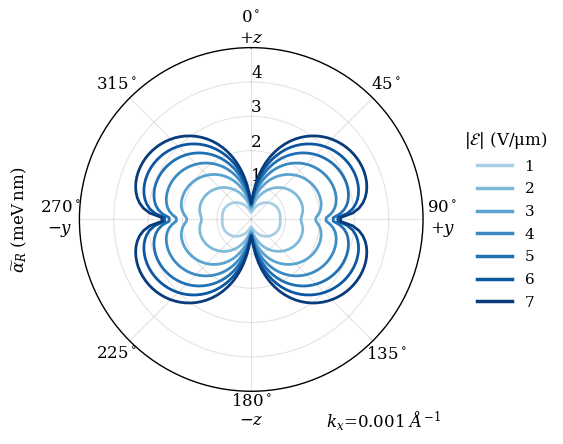

In [3]:
import matplotlib.pyplot as plt
import numpy as np


# ==============================================================
#                         PARAMETERS
# ==============================================================

N = 50
L = 300
kx = 0.001

# Electric-field magnitudes in V/micrometre
electric_fields = np.arange(1.0, 8.0, 1.0)


# ==============================================================
#                      PLOT APPEARANCE
# ==============================================================

plt.rcParams.update({
    "figure.figsize": [5.2, 4.5],
    "font.family": "Serif",
    "mathtext.fontset": "dejavuserif",
    "axes.linewidth": 0.8,
})


def prepare_polar_axis(ax):
    """Set the angular convention for the electric-field rotation."""

    # theta = 0: E || +z
    # theta = 90 degrees: E || +y
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)

    angles_deg = [
        0, 45, 90, 135,
        180, 225, 270, 315,
    ]

    ax.set_xticks(np.deg2rad(angles_deg))

    ax.set_xticklabels([
        r"$0^\circ$" + "\n" + r"$+z$",
        r"$45^\circ$",
        r"$90^\circ$" + "\n" + r"$+y$",
        r"$135^\circ$",
        r"$180^\circ$" + "\n" + r"$-z$",
        r"$225^\circ$",
        r"$270^\circ$" + "\n" + r"$-y$",
        r"$315^\circ$",
    ], fontsize = 12)

    ax.grid(alpha=0.35)
    ax.spines["polar"].set_linewidth(1.0)

    # Radial range and concentric-ring labels
    ax.set_ylim(0, 5)
    ax.set_rticks(np.arange(1, 5, 1))

    # Place the radial labels along the +z axis
    ax.set_rlabel_position(0)

    # Optional: slightly separate the labels from the axis
    ax.tick_params(axis="y", pad=5, labelsize = 12)


# ==============================================================
#                 BLUE SHADES FOR ELECTRIC FIELDS
# ==============================================================

cmap = plt.get_cmap("Blues")

# Avoid the nearly white portion of the Blues colormap
blue_colors = cmap(
    np.linspace(
        0.35,
        0.95,
        len(electric_fields),
    )
)


# ==============================================================
#                  PLOT RASHBA COEFFICIENT
# ==============================================================

fig, ax = plt.subplots(
    figsize=(5.2, 4.5),
    subplot_kw={"projection": "polar"},
)

prepare_polar_axis(ax)


for E, color in zip(electric_fields, blue_colors):

    data_file = (
        f"E_rotation_N{N}_L{L}_"
        f"E{E:.2f}Vum_kx{kx}.dat"
    )

    data = np.loadtxt(
        data_file,
        comments="#",
    )

    if data.ndim != 2 or data.shape[1] < 8:
        raise ValueError(
            f"Expected at least 8 columns in {data_file}, "
            f"but found shape {data.shape}."
        )

    theta = np.deg2rad(data[:, 0])

    # Convert alpha from eV Angstrom to meV nm
    # 1 eV Angstrom = 100 meV nm
    alpha_meV_nm = 100.0 * data[:, 6]

    # Close the polar curve when 360 degrees is not included
    angular_range = theta[-1] - theta[0]

    if not np.isclose(angular_range, 2.0 * np.pi):

        theta_plot = np.append(
            theta,
            theta[0] + 2.0 * np.pi,
        )

        alpha_plot = np.append(
            alpha_meV_nm,
            alpha_meV_nm[0],
        )

    else:
        theta_plot = theta
        alpha_plot = alpha_meV_nm

    ax.plot(
        theta_plot,
        alpha_plot,
        color=color,
        linewidth=2.0,
        label=rf"${E:g}$",
    )


# ==============================================================
#                      LABELS AND LEGEND
# ==============================================================
# ax.text(0.0,-0.15,r"$|\mathcal{E}|$"f"={E}" r" V/$\mu$m", transform=ax2.transAxes,fontsize = 12)
ax.text(0.9,-0.15,r"$k_x$"f"={kx}" r" $\AA^{-1}$", transform=ax2.transAxes,fontsize = 12)

ax.set_ylabel(
    r"$\widetilde{\alpha}_R~(\mathrm{meV\,nm})$",
    labelpad=36, fontsize = 12
)

legend = ax.legend(
    title=r"$|\mathcal{E}|~(\mathrm{V/\mu m})$",
    loc="upper left",
    bbox_to_anchor=(1.08, 0.8),
    frameon=False,
    fontsize=11,
    title_fontsize=12,
    handlelength=2.3,
    labelspacing=0.5,
)

# Ensure the legend lines have a clearly visible thickness
for line in legend.get_lines():
    line.set_linewidth(2.5)


# ==============================================================
#                         SAVE FIGURE
# ==============================================================

fig.tight_layout()

fig.savefig(
    f"polar_alpha_all_E_N{N}_L{L}_kx{kx}.svg",
    bbox_inches="tight",
)

fig.savefig(
    f"polar_alpha_all_E_N{N}_L{L}_kx{kx}.pdf",
    bbox_inches="tight",
)

plt.show()